### Statistical Learning for Data Science 2 (229352)
#### Instructor: Donlapark Ponnoprat

#### [Course website](https://donlapark.pages.dev/229352/)

## Lab #5

#### Load data at: https://donlapark.pages.dev/229352/heart_disease.csv

* Decision tree ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html))
* Random hyperparameter search using cross-validation ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html))

In [1]:
import pandas as pd
import graphviz

from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

# import data
data = pd.read_csv("heart_disease.csv", na_values="?")
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,label
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [2]:

# split into X and y
y = data["label"]
X = data.drop("label", axis=1)

# split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y)

# impute missing values
imputer = SimpleImputer(strategy="mean")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Create a decision tree
clf = DecisionTreeClassifier()

![5CV](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)

In [3]:
params = {'max_depth': [3, 6, 9, 12]}

gridcv = GridSearchCV(clf, params, scoring='accuracy', cv=5)
gridcv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [3, 6, 9, 12]}, scoring='accuracy')

In [4]:
gridcv.best_estimator_

DecisionTreeClassifier(max_depth=3)

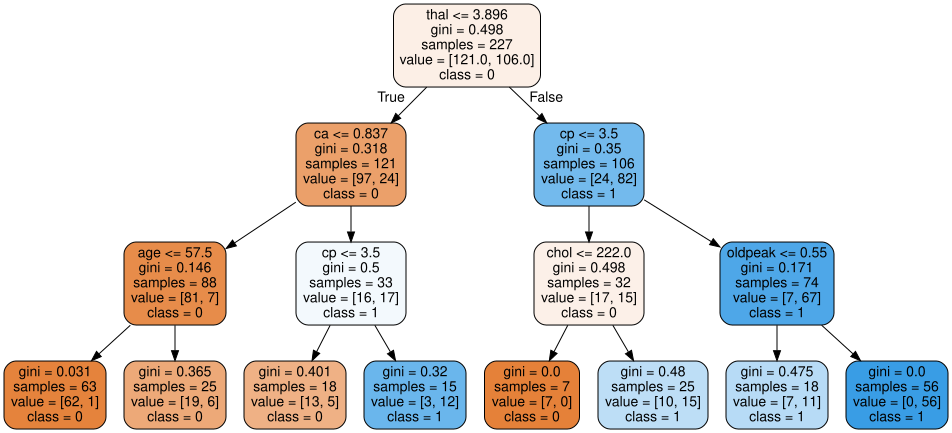

In [5]:
plot_data = export_graphviz(gridcv.best_estimator_,
                            out_file=None,
                            filled=True,
                            rounded=True,
                            feature_names=data.columns[:-1],
                            class_names=['0', '1'])

graph = graphviz.Source(plot_data)
graph

In [6]:
from sklearn.metrics import classification_report

ypred = gridcv.predict(X_test)

print(classification_report(y_test, ypred))

              precision    recall  f1-score   support

           0       0.76      0.81      0.79        43
           1       0.73      0.67      0.70        33

    accuracy                           0.75        76
   macro avg       0.75      0.74      0.74        76
weighted avg       0.75      0.75      0.75        76



## Bagged decision trees
* Bagging classifier ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html))

In [7]:
clf = DecisionTreeClassifier()


bagged_trees =  BaggingClassifier(clf , n_estimators=100, max_samples=X_train.shape[0], max_features = 5)

bagged_trees.fit(X_train, y_train)

ypred_bt = bagged_trees.predict(X_test)

print(classification_report(y_test, ypred_bt))

              precision    recall  f1-score   support

           0       0.72      0.84      0.77        43
           1       0.73      0.58      0.64        33

    accuracy                           0.72        76
   macro avg       0.73      0.71      0.71        76
weighted avg       0.72      0.72      0.72        76



## Random forest classifier
* Random forest ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html))

In [8]:
rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200)

#### Exercise
1. Study the hyperparameters of three models: [Decision tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html), [Bagged Decision Trees](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) and [Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
2. For each model, use pipeline+grid search cross-validation across multiple hyperparameters to find the best model.
* Decision tree: choose at least 3 hyperparameters
* Bagged decision trees: choose at least 3 hyperparameters
* Random forest: choose at least 3 hyperparameters
3. For each model, compute the `f1_macro` and `accuracy` score on the test set.
* What is your best model?
* Plot the best tree model
* What hyperparameters did you choose? (explain in words, not in `sklearn's` parameter name)
* What are the best values of your hyperparameters?

In [9]:
#Pipeline

pipeline = Pipeline([('dt', DecisionTreeClassifier())])


In [10]:
pipeline.get_params()

{'memory': None,
 'steps': [('dt', DecisionTreeClassifier())],
 'transform_input': None,
 'verbose': False,
 'dt': DecisionTreeClassifier(),
 'dt__ccp_alpha': 0.0,
 'dt__class_weight': None,
 'dt__criterion': 'gini',
 'dt__max_depth': None,
 'dt__max_features': None,
 'dt__max_leaf_nodes': None,
 'dt__min_impurity_decrease': 0.0,
 'dt__min_samples_leaf': 1,
 'dt__min_samples_split': 2,
 'dt__min_weight_fraction_leaf': 0.0,
 'dt__monotonic_cst': None,
 'dt__random_state': None,
 'dt__splitter': 'best'}

In [11]:
params = {
    'dt__max_depth' : [3,5,7,9,11],
    'dt__min_samples_split' : [2,5,10],
    'dt__min_samples_leaf': [1,2,4]
}


#grid search
grid = GridSearchCV(pipeline, params, cv=5, scoring='f1_macro', n_jobs=-1)
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Pipeline(steps=[('dt', DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'dt__max_depth': [3, 5, 7, 9, 11],
                         'dt__min_samples_leaf': [1, 2, 4],
                         'dt__min_samples_split': [2, 5, 10]},
             scoring='f1_macro')

In [12]:
grid.best_estimator_

Pipeline(steps=[('dt',
                 DecisionTreeClassifier(max_depth=5, min_samples_leaf=2,
                                        min_samples_split=5))])

#Decision Tree

In [13]:
grid.best_score_

np.float64(0.7993257988997196)

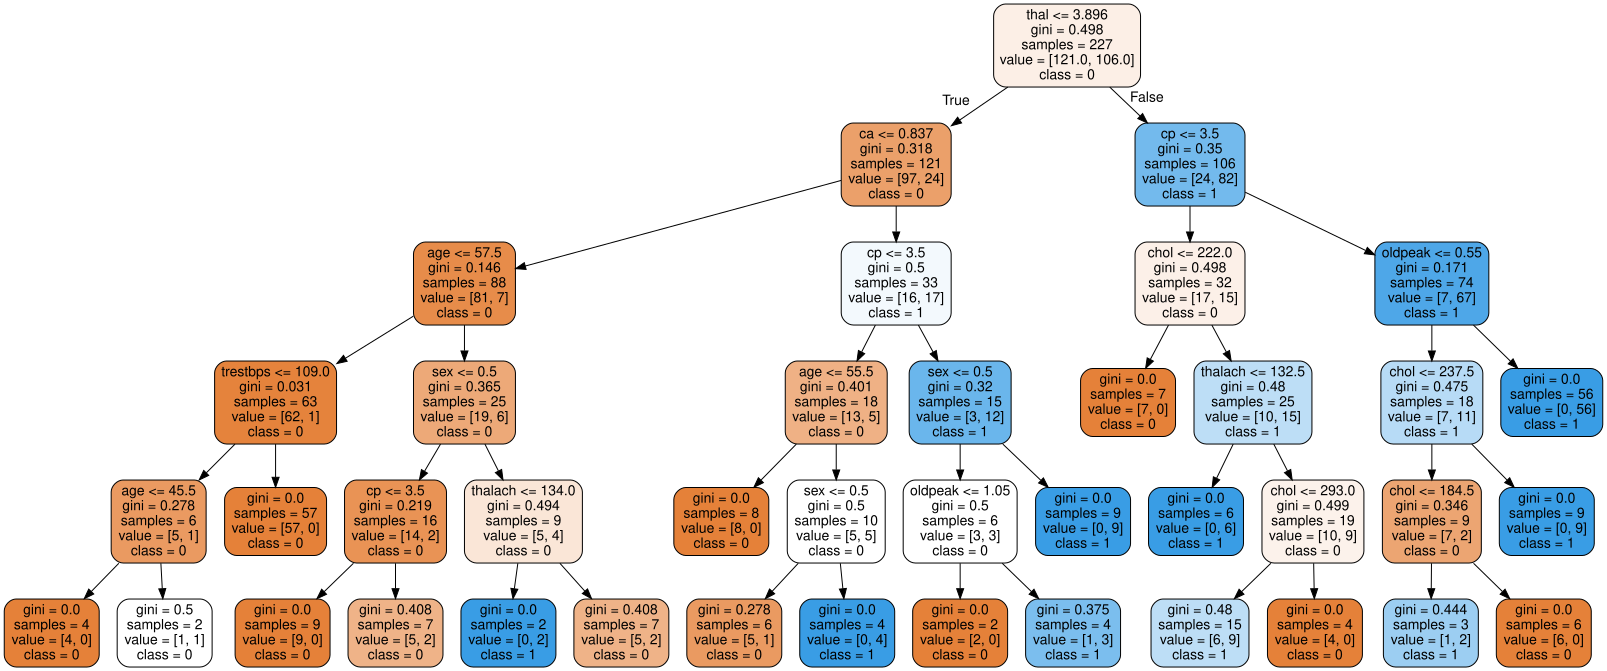

In [14]:
best_dt_model = grid.best_estimator_.named_steps['dt']

plot_data = export_graphviz(best_dt_model,
                            out_file=None,
                            filled=True,
                            rounded=True,
                            feature_names=data.columns[:-1],
                            class_names=['0', '1'])


graph = graphviz.Source(plot_data)
graph

In [15]:
grid.best_params_

{'dt__max_depth': 5, 'dt__min_samples_leaf': 2, 'dt__min_samples_split': 5}

In [16]:
ypred = grid.predict(X_test)

print(classification_report(y_test, ypred))

              precision    recall  f1-score   support

           0       0.71      0.79      0.75        43
           1       0.68      0.58      0.62        33

    accuracy                           0.70        76
   macro avg       0.69      0.68      0.69        76
weighted avg       0.70      0.70      0.69        76



#Bagged Tree

In [17]:
bagged_tree =BaggingClassifier(DecisionTreeClassifier() , n_estimators=100, max_samples=X_train.shape[0], max_features = 5)

bagged_tree.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_features=5,
                  max_samples=227, n_estimators=100)

In [18]:
bagging_pipeline = Pipeline([
    ('bag', BaggingClassifier(estimator=DecisionTreeClassifier()))
])

bagging_pipeline.get_params()

{'memory': None,
 'steps': [('bag', BaggingClassifier(estimator=DecisionTreeClassifier()))],
 'transform_input': None,
 'verbose': False,
 'bag': BaggingClassifier(estimator=DecisionTreeClassifier()),
 'bag__bootstrap': True,
 'bag__bootstrap_features': False,
 'bag__estimator__ccp_alpha': 0.0,
 'bag__estimator__class_weight': None,
 'bag__estimator__criterion': 'gini',
 'bag__estimator__max_depth': None,
 'bag__estimator__max_features': None,
 'bag__estimator__max_leaf_nodes': None,
 'bag__estimator__min_impurity_decrease': 0.0,
 'bag__estimator__min_samples_leaf': 1,
 'bag__estimator__min_samples_split': 2,
 'bag__estimator__min_weight_fraction_leaf': 0.0,
 'bag__estimator__monotonic_cst': None,
 'bag__estimator__random_state': None,
 'bag__estimator__splitter': 'best',
 'bag__estimator': DecisionTreeClassifier(),
 'bag__max_features': 1.0,
 'bag__max_samples': 1.0,
 'bag__n_estimators': 10,
 'bag__n_jobs': None,
 'bag__oob_score': False,
 'bag__random_state': None,
 'bag__verbose': 

In [20]:
bagging_params = {
    'bag__estimator__max_depth' : [3,5,7,9,11],
    'bag__estimator__min_samples_split' : [2,5,10],
    'bag__estimator__min_samples_leaf': [1,2,4]
}


grid_bagged = GridSearchCV(bagging_pipeline, bagging_params, cv=5, scoring='f1_macro', n_jobs=-1)
grid_bagged.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('bag',
                                        BaggingClassifier(estimator=DecisionTreeClassifier()))]),
             n_jobs=-1,
             param_grid={'bag__estimator__max_depth': [3, 5, 7, 9, 11],
                         'bag__estimator__min_samples_leaf': [1, 2, 4],
                         'bag__estimator__min_samples_split': [2, 5, 10]},
             scoring='f1_macro')

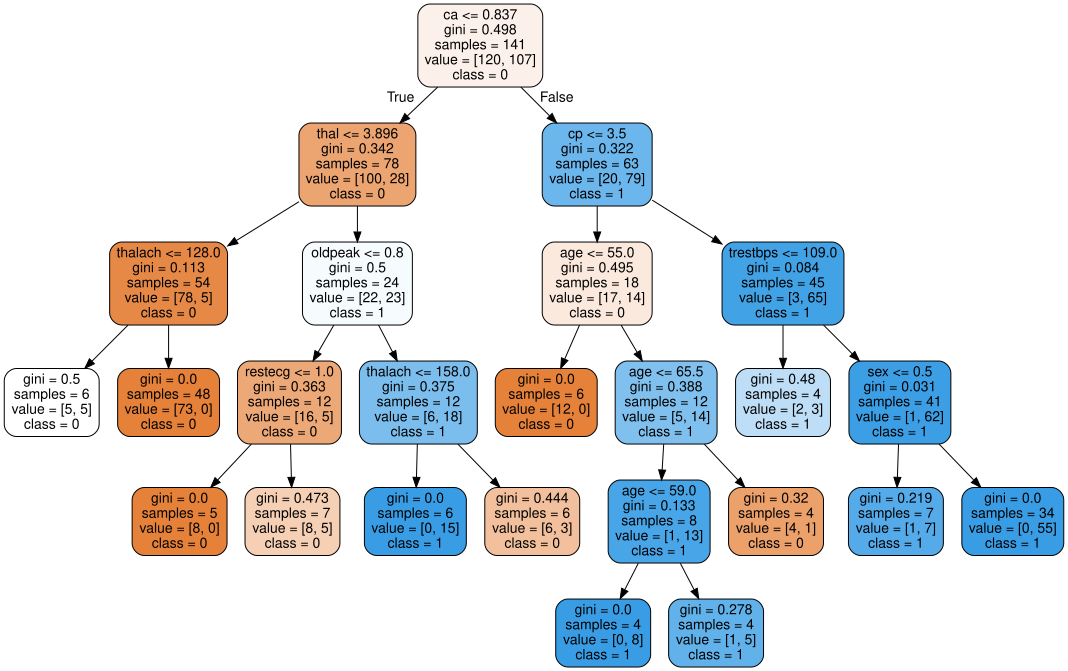

In [21]:
bagging_classifier_model = grid_bagged.best_estimator_.named_steps['bag']

first_tree_estimator = bagging_classifier_model.estimators_[0]


feature_indices_for_tree = bagging_classifier_model.estimators_features_[0]
selected_feature_names = data.columns[feature_indices_for_tree]


plot_data = export_graphviz(first_tree_estimator,
                            out_file=None,
                            filled=True,
                            rounded=True,
                            feature_names=selected_feature_names,
                            class_names=['0', '1'])


graph = graphviz.Source(plot_data)
graph

In [22]:
grid_bagged.best_estimator_

Pipeline(steps=[('bag',
                 BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=7,
                                                                    min_samples_leaf=4,
                                                                    min_samples_split=5)))])

In [23]:
ypred_bagged = grid_bagged.predict(X_test)

print(classification_report(y_test, ypred_bagged))

              precision    recall  f1-score   support

           0       0.73      0.84      0.78        43
           1       0.74      0.61      0.67        33

    accuracy                           0.74        76
   macro avg       0.74      0.72      0.72        76
weighted avg       0.74      0.74      0.73        76



#Random Forest

In [24]:
pipeline_rf = Pipeline([("rf", RandomForestClassifier(n_estimators=200))])

pipeline_rf.get_params()

{'memory': None,
 'steps': [('rf', RandomForestClassifier(n_estimators=200))],
 'transform_input': None,
 'verbose': False,
 'rf': RandomForestClassifier(n_estimators=200),
 'rf__bootstrap': True,
 'rf__ccp_alpha': 0.0,
 'rf__class_weight': None,
 'rf__criterion': 'gini',
 'rf__max_depth': None,
 'rf__max_features': 'sqrt',
 'rf__max_leaf_nodes': None,
 'rf__max_samples': None,
 'rf__min_impurity_decrease': 0.0,
 'rf__min_samples_leaf': 1,
 'rf__min_samples_split': 2,
 'rf__min_weight_fraction_leaf': 0.0,
 'rf__monotonic_cst': None,
 'rf__n_estimators': 200,
 'rf__n_jobs': None,
 'rf__oob_score': False,
 'rf__random_state': None,
 'rf__verbose': 0,
 'rf__warm_start': False}

In [25]:
rf_params =  {
    'rf__max_depth': [1,3,5],
    'rf__max_samples': [4,5,7],
    'rf__min_samples_leaf': [1,3,5]

}

grid_rf = GridSearchCV(pipeline_rf, rf_params, cv=5, scoring='f1_macro', n_jobs=-1)
grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('rf',
                                        RandomForestClassifier(n_estimators=200))]),
             n_jobs=-1,
             param_grid={'rf__max_depth': [1, 3, 5],
                         'rf__max_samples': [4, 5, 7],
                         'rf__min_samples_leaf': [1, 3, 5]},
             scoring='f1_macro')

In [26]:
grid_rf.best_score_

np.float64(0.8740827695188347)

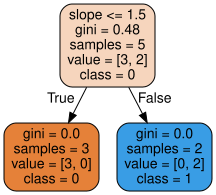

In [27]:
best_rf_pipeline = grid_rf.best_estimator_
best_rf_classifier = best_rf_pipeline.named_steps['rf']


first_rf_tree = best_rf_classifier.estimators_[0]

plot_data = export_graphviz(first_rf_tree,
                            out_file=None,
                            filled=True,
                            rounded=True,
                            feature_names=data.columns[:-1],
                            class_names=['0','1'])
graph = graphviz.Source(plot_data)
graph

In [28]:
grid_rf.best_params_

{'rf__max_depth': 3, 'rf__max_samples': 5, 'rf__min_samples_leaf': 1}

In [29]:
ypred_rf = rf.predict(X_test)
print(classification_report(y_test, ypred_rf))

              precision    recall  f1-score   support

           0       0.75      0.84      0.79        43
           1       0.75      0.64      0.69        33

    accuracy                           0.75        76
   macro avg       0.75      0.74      0.74        76
weighted avg       0.75      0.75      0.75        76



# Summary of 3 model
* max_depth ใช้เพื่อหาความลึกของข้อมูล
* min_samples_split เพื่อหาNodeน้อยสุดของการก่อนแบ่งข้อมูล
* min_samples_leaf หาโหนดที่เป็นไปได้หลังจากแบ่ง


In [ ]:
f1_rf= classification_report(y_test, ypred_rf, output_dict=True)

3. For each model, compute the `f1_macro` and `accuracy` score on the test set.
* What is your best model?
* Plot the best tree model
* What hyperparameters did you choose? (explain in words, not in `sklearn's` parameter name)
* What are the best values of your hyperparameters?

In [51]:
# Decision Tree accuracy
acc_dt = classification_report(y_test, ypred, output_dict=True)['accuracy']
# bagged Tree accuracy
acc_bagged = classification_report(y_test, ypred_bagged, output_dict=True)['accuracy']
#Random Tree accuracy
acc_rf = classification_report(y_test, ypred_rf, output_dict=True)['accuracy']

In [49]:
# Decision Tree f1
f1_dt = classification_report(y_test, ypred, output_dict=True)['macro avg']['f1-score']
# bagged Tree f1
f1_bagged = classification_report(y_test, ypred_bagged, output_dict=True)['macro avg']['f1-score']
#Random Tree f1
f1_rf = classification_report(y_test, ypred_rf, output_dict=True)['macro avg']['f1-score']

In [66]:
best_model = dict()
best_model['dt'] = [acc_dt]
best_model['bagged'] = [acc_bagged]
best_model['random'] = [acc_rf]
best_model_sorted = dict(sorted(best_model.items(), key=lambda item: item[1][0], reverse=True))
print('best model for accuracy', best_model_sorted )

best model for accuracy {'random': [0.75], 'bagged': [0.7368421052631579], 'dt': [0.6973684210526315]}


In [68]:
f1_model = dict()
f1_model['dt-f1'] = [f1_dt]
f1_model['bagged-f1'] = [f1_bagged]
f1_model['random-f1'] = [f1_rf]
f1_model_sorted = dict(sorted(f1_model.items(), key=lambda item: item[1][0], reverse=True))
print('best model for f1-score', best_model_sorted )

best model for f1-score {'random': [0.75], 'bagged': [0.7368421052631579], 'dt': [0.6973684210526315]}


In [71]:
grid_rf.best_params_

{'rf__max_depth': 3, 'rf__max_samples': 5, 'rf__min_samples_leaf': 1}

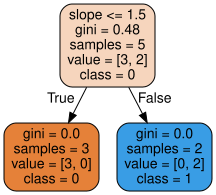

In [72]:
best_rf_pipeline = grid_rf.best_estimator_
best_rf_classifier = best_rf_pipeline.named_steps['rf']

first_rf_tree = best_rf_classifier.estimators_[0]

plot_data_rf = export_graphviz(first_rf_tree,
                            out_file=None,
                            filled=True,
                            rounded=True,
                            feature_names=data.columns[:-1],
                            class_names=['0','1'])

graph_rf = graphviz.Source(plot_data_rf)
graph_rf